<a href="https://colab.research.google.com/github/SamsondareHUB/Synthetic-MRI-motion-detection/blob/main/02_motion_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip install -q torchio nibabel pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.6/203.6 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 24.2 MB/s eta 0:00:00


In [4]:
from pathlib import Path
import glob
import random

import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torchio as tio

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

ROOT = Path("/content/drive/MyDrive/synthetic-mri-motion-detection")

RAW_SAMPLE_DIR = ROOT / "data" / "raw" / "sample"
PROCESSED_DIR = ROOT / "data" / "processed"
SYNTHETIC_DIR = ROOT / "data" / "synthetic"
FIGURE_DIR = ROOT / "outputs" / "figures"

SYNTHETIC_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

central_metadata_df = pd.read_csv(
    PROCESSED_DIR / "central_slice_metadata.csv"
)

nii_files = sorted(
    glob.glob(str(RAW_SAMPLE_DIR / "*.nii"))
    + glob.glob(str(RAW_SAMPLE_DIR / "*.nii.gz"))
)

print("Raw MRI volumes:", len(nii_files))
print("Central clean slices:", len(central_metadata_df))
print("TorchIO version:", tio.__version__)

Raw MRI volumes: 10
Central clean slices: 1455
TorchIO version: 1.2.1


In [6]:
moderate_motion = tio.RandomMotion(
    degrees=(2, 4),
    translation=(2, 4),
    num_transforms=4,
    image_interpolation="linear",
)

In [8]:
sample_nifti = nii_files[0]

clean_img = nib.load(sample_nifti)
clean_img = nib.as_closest_canonical(clean_img)

clean_volume = clean_img.get_fdata().astype(np.float32)

subject_id = (
    Path(sample_nifti).name
    .replace("-T1.nii.gz", "")
    .replace("-T1.nii", "")
)

subject = tio.Subject(
    mri=tio.ScalarImage(tensor=clean_volume[np.newaxis, ...])
)

corrupted_subject = moderate_motion(subject)
corrupted_volume = corrupted_subject.mri.data.squeeze(0).numpy()

print("Subject:", subject_id)
print("Clean volume shape:", clean_volume.shape)
print("Corrupted volume shape:", corrupted_volume.shape)

Subject: IXI002-Guys-0828
Clean volume shape: (150, 256, 256)
Corrupted volume shape: (150, 256, 256)


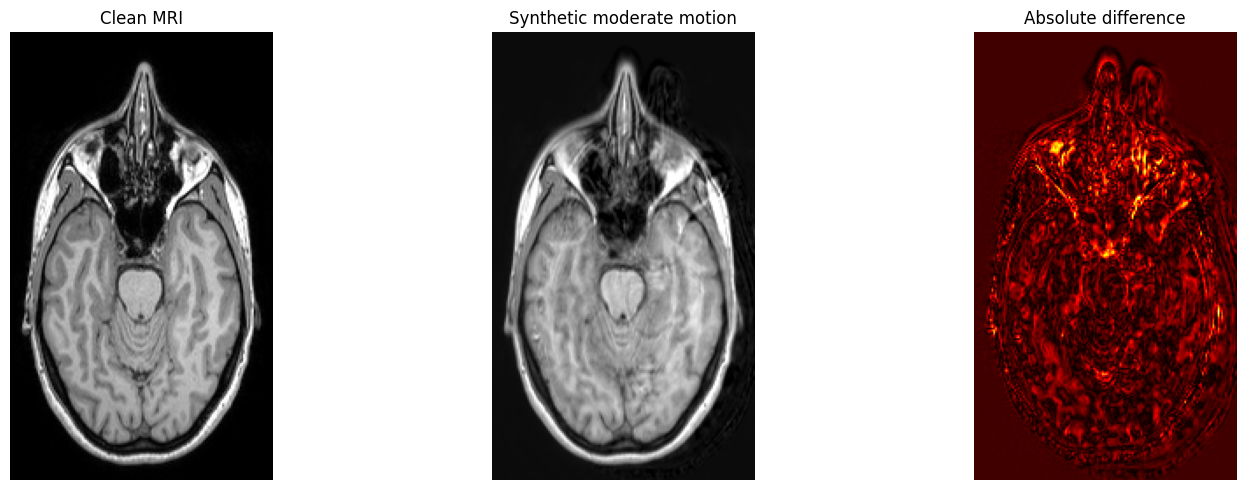

Displayed central slice index: 112
Saved: /content/drive/MyDrive/synthetic-mri-motion-detection/outputs/figures/clean_vs_moderate_motion.png


In [9]:
def normalize_for_display(image):
    low, high = np.percentile(image, (1, 99))
    image = np.clip(image, low, high)

    if high > low:
        image = (image - low) / (high - low)

    return image

subject_rows = central_metadata_df[
    central_metadata_df["subject_id"] == subject_id
].sort_values("slice_index")

slice_index = int(subject_rows.iloc[len(subject_rows) // 2]["slice_index"])

clean_slice = normalize_for_display(clean_volume[:, :, slice_index])
corrupted_slice = normalize_for_display(
    corrupted_volume[:, :, slice_index]
)

difference = np.abs(clean_slice - corrupted_slice)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(np.rot90(clean_slice), cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Clean MRI")
axes[0].axis("off")

axes[1].imshow(np.rot90(corrupted_slice), cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Synthetic moderate motion")
axes[1].axis("off")

axes[2].imshow(np.rot90(difference), cmap="hot")
axes[2].set_title("Absolute difference")
axes[2].axis("off")

plt.tight_layout()

comparison_path = FIGURE_DIR / "clean_vs_moderate_motion.png"
plt.savefig(comparison_path, dpi=200, bbox_inches="tight")
plt.show()

print("Displayed central slice index:", slice_index)
print("Saved:", comparison_path)

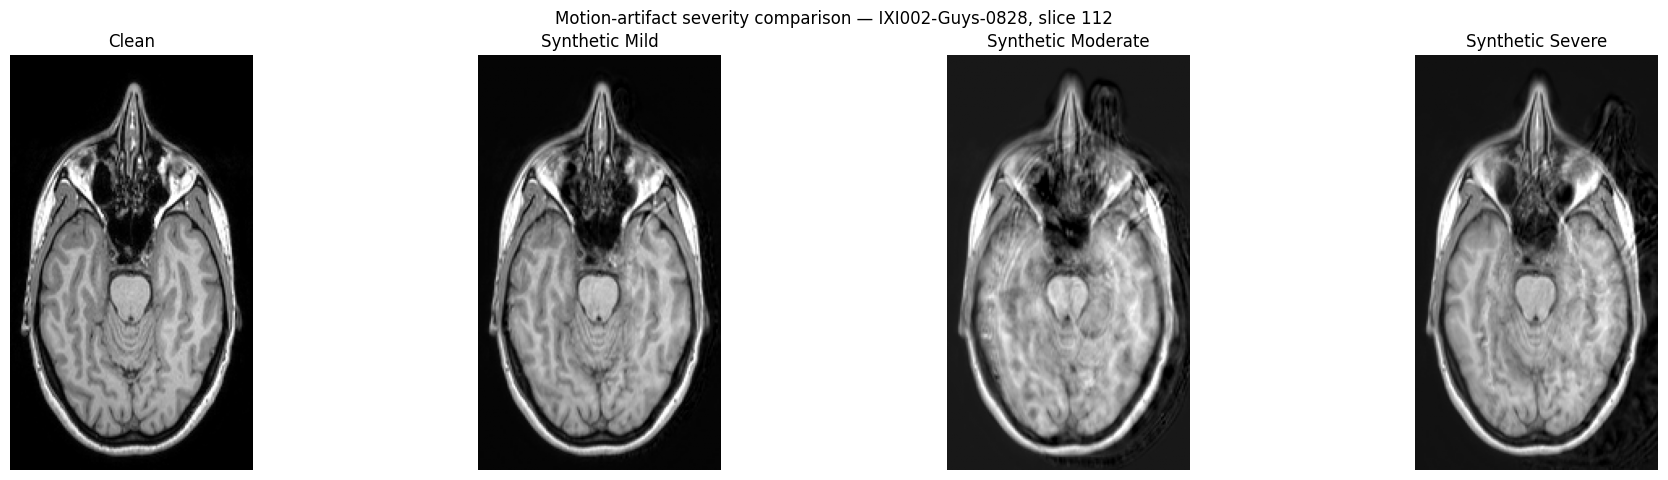

Saved: /content/drive/MyDrive/synthetic-mri-motion-detection/outputs/figures/motion_severity_comparison.png


In [10]:
mild_motion = tio.RandomMotion(
    degrees=(1, 2),
    translation=(1, 2),
    num_transforms=2,
    image_interpolation="linear",
)

moderate_motion = tio.RandomMotion(
    degrees=(2, 4),
    translation=(2, 4),
    num_transforms=4,
    image_interpolation="linear",
)

severe_motion = tio.RandomMotion(
    degrees=(5, 8),
    translation=(5, 8),
    num_transforms=4,
    image_interpolation="linear",
)

motion_transforms = {
    "Mild": mild_motion,
    "Moderate": moderate_motion,
    "Severe": severe_motion,
}

subject = tio.Subject(
    mri=tio.ScalarImage(tensor=clean_volume[np.newaxis, ...])
)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(np.rot90(normalize_for_display(clean_volume[:, :, slice_index])), cmap="gray")
axes[0].set_title("Clean")
axes[0].axis("off")

for ax, (severity, transform) in zip(axes[1:], motion_transforms.items()):
    corrupted = transform(subject)
    corrupted_volume_test = corrupted.mri.data.squeeze(0).numpy()

    corrupted_slice_test = normalize_for_display(
        corrupted_volume_test[:, :, slice_index]
    )

    ax.imshow(np.rot90(corrupted_slice_test), cmap="gray")
    ax.set_title(f"Synthetic {severity}")
    ax.axis("off")

plt.suptitle(
    f"Motion-artifact severity comparison — {subject_id}, slice {slice_index}",
    y=0.95
)
plt.tight_layout()

severity_path = FIGURE_DIR / "motion_severity_comparison.png"
plt.savefig(severity_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", severity_path)